# 🏃 Activity Recognition Model Training
## Phase 1: ML-Based Human Activity Recognition (HAR)

**Project:** Goal-Aware, Activity-Driven Personalized Nutrition Recommendation System

This notebook implements the activity recognition pipeline:
1. Data loading and preprocessing
2. Feature extraction
3. Model training (Random Forest, XGBoost, LightGBM)
4. SHAP-based explainability
5. Sensor fusion evaluation

---

In [32]:
%pip install nbformat

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# Run the setup notebook first
%run colab_setup.ipynb

Successfully connected to local path: c:\Users\joshw\OneDrive\Desktop\FYP_Work
📁 Configured Paths:
   Dataset Root: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset
   Models: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models
   Phone Accel: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset/raw/phone/accel
   Phone Gyro: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset/raw/phone/gyro
   Watch Accel: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset/raw/watch/accel
   Watch Gyro: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Datasets/wisdm-dataset/raw/watch/gyro
All libraries imported successfully!

 Package Versions:
   NumPy: 2.4.1
   Pandas: 2.3.3
   XGBoost: 3.1.3
   LightGBM: 4.6.0
   SHAP: 0.50.0
WISDM Activity Labels:
   ⭐ A: Walking
   ⭐ B: Jogging
      C: Stairs
   ⭐ D: Sitting
   ⭐ E: Standing
      F: Typing
      G: Brushing Teeth
      H: Eating Soup
      I: Eating Chips
      J: Eating Pasta
      K: Drinking
      L: Ea

In [ ]:
## Load and Explore Data

# Load all WISDM data
wisdm_data = load_all_wisdm_data()

Loading WISDM Dataset...



Loading watch gyro: 100%|██████████| 51/51 [00:14<00:00,  3.62it/s]



Data Loading Complete!

Dataset Summary:
   phone_accel: 4,804,403 samples, 51 subjects
   phone_gyro: 3,608,635 samples, 51 subjects
   watch_accel: 3,777,046 samples, 51 subjects
   watch_gyro: 3,440,342 samples, 51 subjects


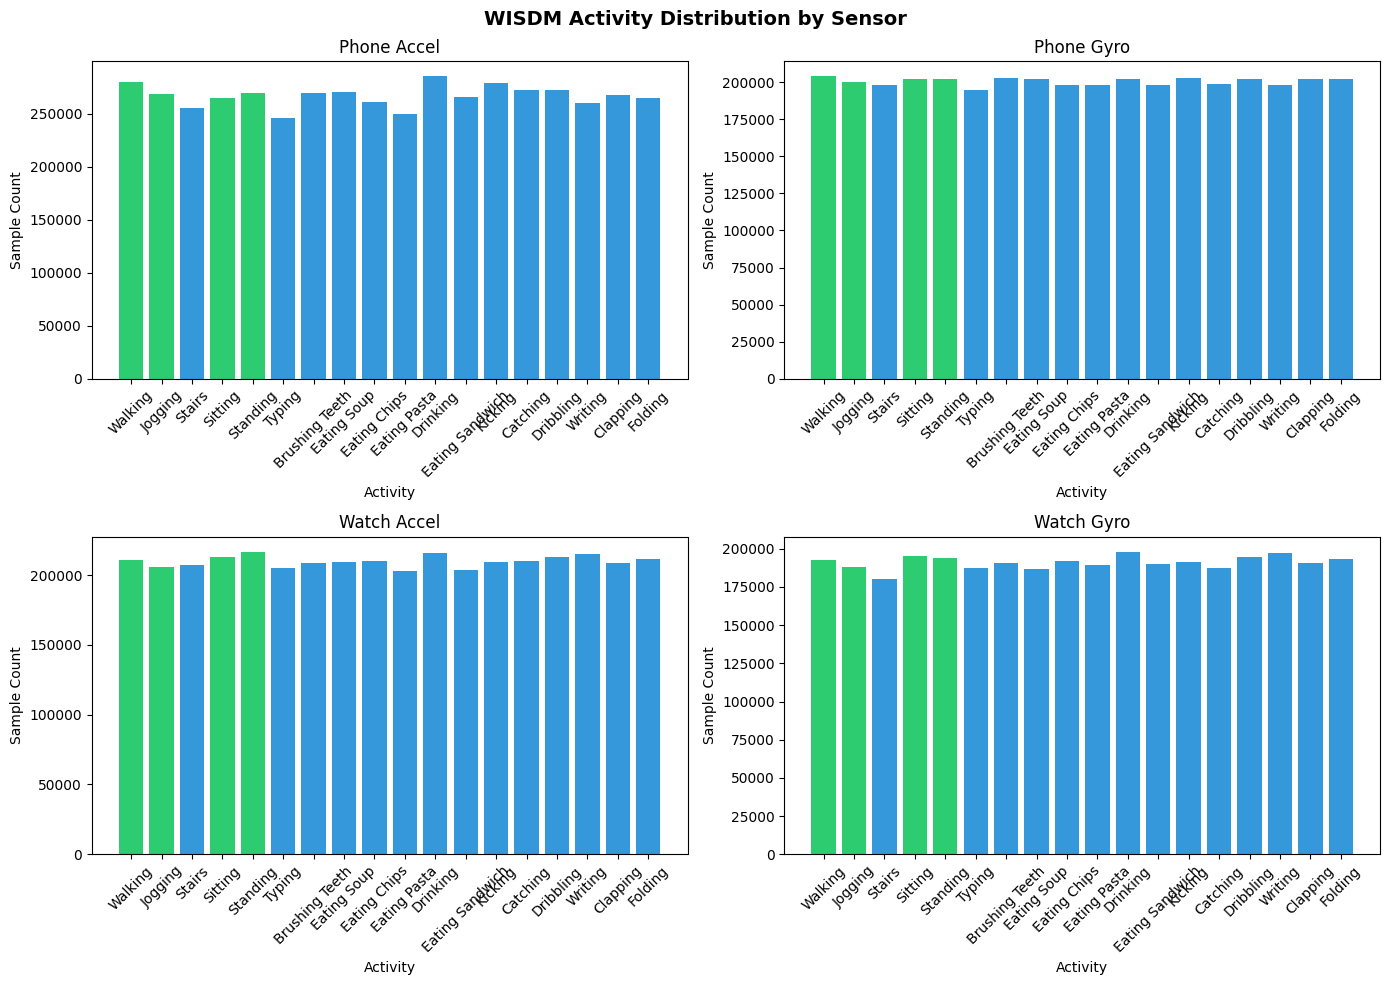

In [35]:
# Explore activity distribution
def plot_activity_distribution(data, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for idx, (key, df) in enumerate(data.items()):
        if df.empty:
            continue
        ax = axes[idx // 2, idx % 2]
        
        activity_counts = df['activity'].value_counts().sort_index()
        activity_names = [ACTIVITY_LABELS.get(a, a) for a in activity_counts.index]
        
        bars = ax.bar(activity_names, activity_counts.values, 
                      color=['#2ecc71' if a in PRIMARY_ACTIVITIES else '#3498db' 
                             for a in activity_counts.index])
        ax.set_title(f'{key.replace("_", " ").title()}')
        ax.set_xlabel('Activity')
        ax.set_ylabel('Sample Count')
        ax.tick_params(axis='x', rotation=45)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_activity_distribution(wisdm_data, 'WISDM Activity Distribution by Sensor')

In [36]:
# Filter to primary activities for nutritional relevance
def filter_primary_activities(data):
    filtered = {}
    for key, df in data.items():
        if not df.empty:
            filtered[key] = df[df['activity'].isin(PRIMARY_ACTIVITIES)].copy()
    return filtered

primary_data = filter_primary_activities(wisdm_data)
print("Primary Activities Data:")
for key, df in primary_data.items():
    print(f"   {key}: {len(df):,} samples")

Primary Activities Data:
   phone_accel: 1,082,422 samples
   phone_gyro: 808,892 samples
   watch_accel: 845,829 samples
   watch_gyro: 769,517 samples


In [ ]:
## Feature Engineering

# Parameters
WINDOW_SIZE = 200  # ~4 seconds at 50Hz
STEP_SIZE = 100    # 50% overlap

# Create windows for phone accelerometer
print("Creating sliding windows for phone accelerometer...")
phone_accel_windows, phone_accel_labels, phone_accel_subjects = create_sliding_windows(
    primary_data['phone_accel'], WINDOW_SIZE, STEP_SIZE
)
print(f"   Windows: {len(phone_accel_windows)}, Shape: {phone_accel_windows.shape}")

Creating sliding windows for phone accelerometer...
   Windows: 10518, Shape: (10518, 200, 3)


In [38]:
# Extract features
print("Extracting features...")
X_phone_accel = extract_features(phone_accel_windows)
y_phone_accel = phone_accel_labels

print(f"\nFeature extraction complete!")
print(f"   Feature matrix shape: {X_phone_accel.shape}")
print(f"   Features: {list(X_phone_accel.columns)[:10]}...")

Extracting features...


Extracting features: 100%|██████████| 10518/10518 [01:01<00:00, 169.86it/s]



Feature extraction complete!
   Feature matrix shape: (10518, 58)
   Features: ['x_mean', 'x_std', 'x_min', 'x_max', 'x_range', 'x_median', 'x_mad', 'x_iqr', 'x_skew', 'x_kurtosis']...


In [39]:
# Handle NaN/Inf values
X_phone_accel = X_phone_accel.replace([np.inf, -np.inf], np.nan)
X_phone_accel = X_phone_accel.fillna(0)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_phone_accel)

print(f"Classes: {le.classes_}")
print(f"Class distribution: {np.bincount(y_encoded)}")

Classes: ['A' 'B' 'D' 'E']
Class distribution: [2721 2611 2567 2619]


In [ ]:
## Model Training

# Subject-wise split to prevent data leakage
unique_subjects = np.unique(phone_accel_subjects)
train_subjects, test_subjects = train_test_split(unique_subjects, test_size=0.2, random_state=42)

train_mask = np.isin(phone_accel_subjects, train_subjects)
test_mask = np.isin(phone_accel_subjects, test_subjects)

X_train, X_test = X_phone_accel[train_mask], X_phone_accel[test_mask]
y_train, y_test = y_encoded[train_mask], y_encoded[test_mask]

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Training subjects: {len(train_subjects)}, Test subjects: {len(test_subjects)}")

Training samples: 8504, Test samples: 2014
Training subjects: 40, Test subjects: 11


In [41]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# Train models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                                   random_state=42, use_label_encoder=False, 
                                   eval_metric='mlogloss', n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                    random_state=42, n_jobs=-1, verbose=-1)
}

results = {}

for name, model in models.items():
    print(f"\n Training {name}...")
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {'model': model, 'accuracy': acc, 'f1': f1, 'predictions': y_pred}
    print(f"   Accuracy: {acc:.4f}")
    print(f"   F1 Score: {f1:.4f}")


 Training Random Forest...


   Accuracy: 0.8942
   F1 Score: 0.8935

 Training XGBoost...
   Accuracy: 0.8813
   F1 Score: 0.8802

 Training LightGBM...
   Accuracy: 0.8972
   F1 Score: 0.8966



📊 Model Comparison:
        Model  Accuracy  F1 Score
     LightGBM  0.897219  0.896554
Random Forest  0.894240  0.893540
      XGBoost  0.881331  0.880208


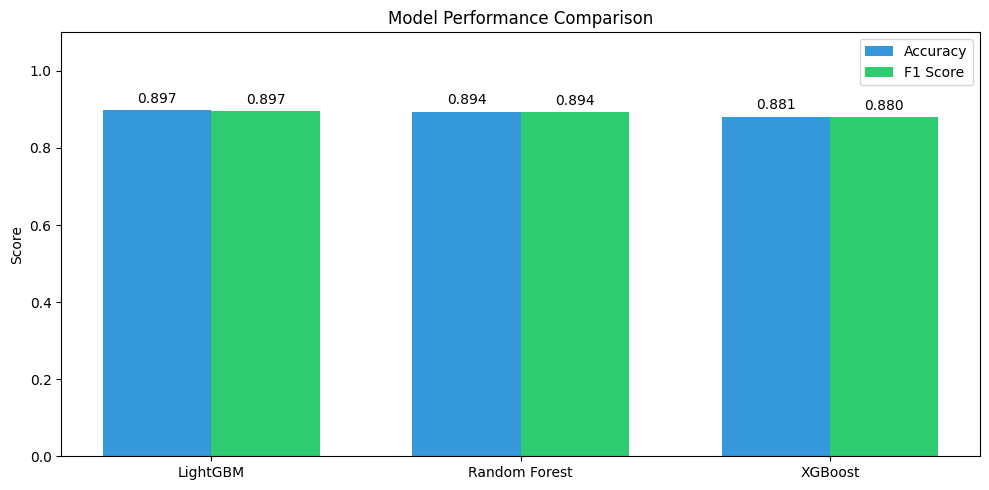

In [ ]:
# Compare models
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'F1 Score': [r['f1'] for r in results.values()]
}).sort_values('F1 Score', ascending=False)

print("\nModel Comparison:")
print(comparison_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy', color='#3498db')
bars2 = ax.bar(x + width/2, comparison_df['F1 Score'], width, label='F1 Score', color='#2ecc71')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')

plt.tight_layout()
plt.show()

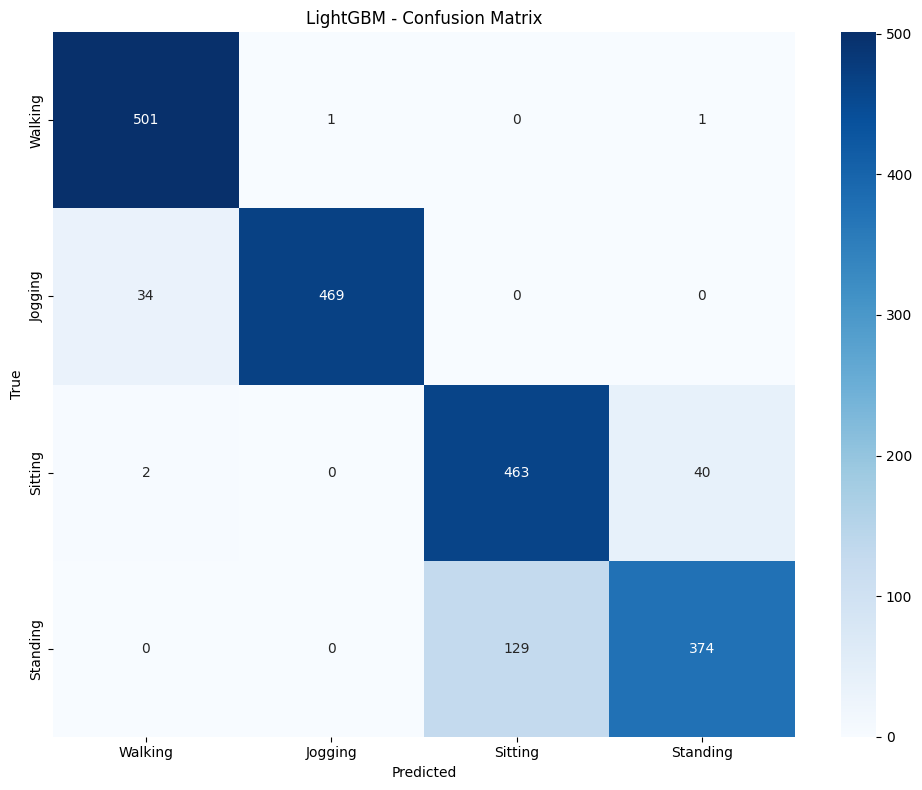


Classification Report (LightGBM):
              precision    recall  f1-score   support

     Walking       0.93      1.00      0.96       503
     Jogging       1.00      0.93      0.96       503
     Sitting       0.78      0.92      0.84       505
    Standing       0.90      0.74      0.81       503

    accuracy                           0.90      2014
   macro avg       0.90      0.90      0.90      2014
weighted avg       0.90      0.90      0.90      2014



In [44]:
# Confusion matrix for best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

cm = confusion_matrix(y_test, best_predictions)
class_names = [ACTIVITY_LABELS.get(c, c) for c in le.classes_]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'{best_model_name} - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print(f"\nClassification Report ({best_model_name}):")
print(classification_report(y_test, best_predictions, target_names=class_names))

In [ ]:
## SHAP Explainability

# SHAP analysis for best model
print(f"🔍 Computing SHAP values for {best_model_name}...")

# Use a sample for faster computation
sample_size = min(500, len(X_test_scaled))
X_sample = X_test_scaled[:sample_size]

if best_model_name == 'Random Forest':
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_sample)

🔍 Computing SHAP values for LightGBM...


Top 15 Most Important Features (SHAP):
         feature  importance
         mag_std    1.471330
      z_fft_mean    0.667062
           y_mad    0.613403
           y_std    0.307570
        mag_mean    0.275645
y_zero_crossings    0.260258
           z_rms    0.258476
           y_rms    0.185375
           y_iqr    0.179137
x_zero_crossings    0.173961
   z_fft_entropy    0.169462
           x_min    0.164506
       z_fft_max    0.153727
z_zero_crossings    0.152345
       y_fft_max    0.138816


<Figure size 1200x800 with 0 Axes>

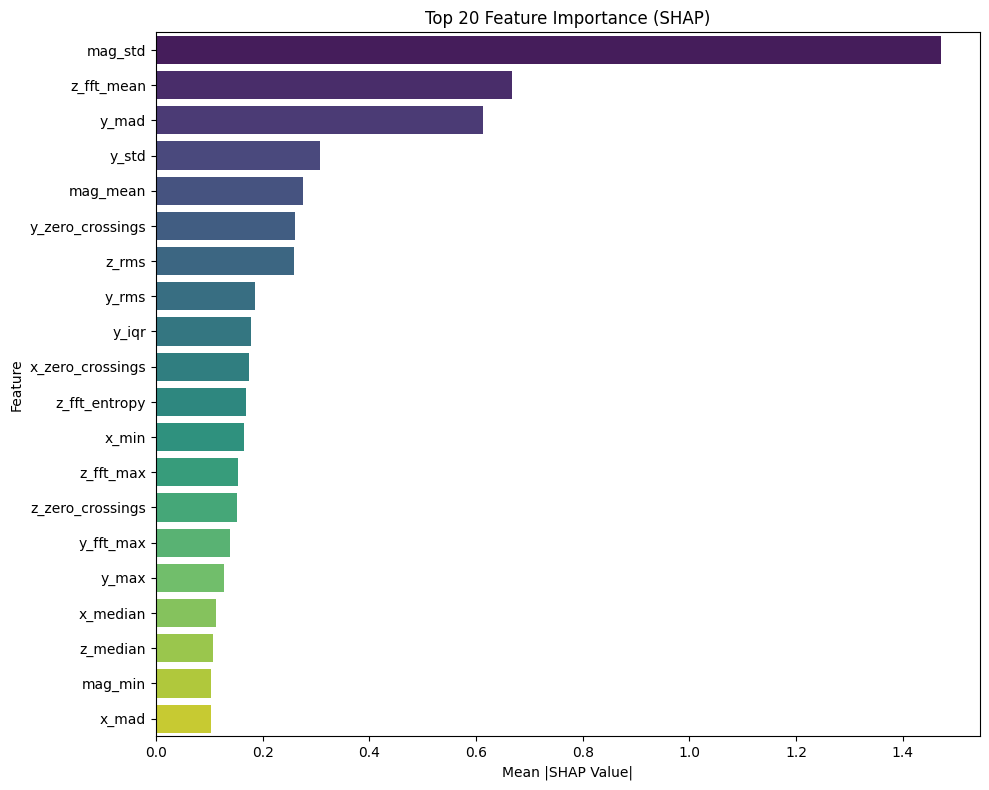

In [46]:
# SHAP summary plot
plt.figure(figsize=(12, 8))
feature_names = list(X_phone_accel.columns)

# For multiclass, take mean absolute SHAP across classes
if isinstance(shap_values, list):
    # Mean absolute SHAP across classes (list of arrays)
    shap_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
elif len(shap_values.shape) == 3:
    # Mean absolute SHAP across classes (3rd dimension of array)
    shap_mean = np.mean(np.abs(shap_values), axis=-1)
else:
    # Binary classification or regression (2D array)
    shap_mean = np.abs(shap_values)

# Calculate mean importance across all samples
# shap_mean is now guaranteed to be (samples x features)
feature_importance_values = np.mean(shap_mean, axis=0)

# Top features
feature_names = list(X_phone_accel.columns)
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': np.mean(shap_mean, axis=0)
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features (SHAP):")
print(feature_importance.head(15).to_string(index=False))

# Plot top features
plt.figure(figsize=(10, 8))
top_n = 20
top_features = feature_importance.head(top_n)
sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title(f'Top {top_n} Feature Importance (SHAP)')
plt.xlabel('Mean |SHAP Value|')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
## Save Best Model

# Save the best model
model_name = f'har_{best_model_name.lower().replace(" ", "_")}_phone_accel'
save_model(best_model, model_name, scaler, le)

# Save feature names for inference
feature_path = os.path.join(MODELS_PATH, model_name, 'feature_names.joblib')
joblib.dump(feature_names, feature_path)
print(f"✅ Feature names saved to: {feature_path}")

✅ Model saved to: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models\har_lightgbm_phone_accel
✅ Feature names saved to: c:\Users\joshw\OneDrive\Desktop\FYP_Work\Models\har_lightgbm_phone_accel\feature_names.joblib


In [ ]:
# Save training results
results_summary = {
    'best_model': best_model_name,
    'accuracy': results[best_model_name]['accuracy'],
    'f1_score': results[best_model_name]['f1'],
    'classes': list(le.classes_),
    'n_features': len(feature_names),
    'window_size': WINDOW_SIZE,
    'step_size': STEP_SIZE,
    'activities': [ACTIVITY_LABELS.get(c, c) for c in le.classes_]
}

results_path = os.path.join(MODELS_PATH, model_name, 'training_results.joblib')
joblib.dump(results_summary, results_path)
print(f"Training results saved!")
print(f"\nSummary:")
for key, value in results_summary.items():
    print(f"   {key}: {value}")

✅ Training results saved!

📊 Summary:
   best_model: LightGBM
   accuracy: 0.897219463753724
   f1_score: 0.8965542434175041
   classes: [np.str_('A'), np.str_('B'), np.str_('D'), np.str_('E')]
   n_features: 58
   window_size: 200
   step_size: 100
   activities: ['Walking', 'Jogging', 'Sitting', 'Standing']


---
## 🎉 Training Complete!

**Next Steps:**
1. Train watch-only model for comparison
2. Implement sensor fusion (phone + watch)
3. Integrate with rule-based nutrition engine
4. Deploy to Flutter mobile app

---
*FYP: Goal-Aware, Activity-Driven Personalized Nutrition Recommendation System*